In [78]:
#Imports 
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
import sklearn
from sklearn.linear_model import Perceptron
from sklearn import metrics
from sklearn.linear_model import LinearRegression
import seaborn as sns

In [2]:
Combine_Data = pd.read_csv("2021Combine.csv")
Combine_Data.head()

,Name,Pos,School,Height,Weight,Hands,Arms,Wingspan,40 Yd,10 Split,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,NaN,NaN,NaN,4.60,NaN,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,NaN,NaN,NaN,4.61,NaN,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,NaN,NaN,NaN,4.52,NaN,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,NaN,NaN,NaN,4.51,NaN,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,NaN,NaN,NaN,4.27,NaN,32.0,"10'3""",NaN,7.13,4.25


In [65]:
Combine_df = pd.DataFrame(Combine_Data)
Combine_df = Combine_df.drop(['Hands', 'Arms', 'Wingspan', '10 Split'], axis = 1)
Combine_df.head()

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,4.60,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,4.61,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",NaN,7.13,4.25


In [4]:
WR_df = Combine_df.loc[Combine_df['Pos'] == 'WR']
WR_df.head()

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle
0,Adam Krumholz,WR,Wisconsin,"6'0""",193.0,4.60,35.5,"9'10""",11.0,7.03,4.28
1,Adrian Hardy,WR,Louisiana Tech,"6'1""",205.0,4.61,37.5,"10'4""",12.0,6.96,4.50
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",NaN,7.13,4.25


In [66]:
WR_df = WR_df.fillna(0)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(WR_df)

                         Name Pos           School Height  Weight  40 Yd  \
0               Adam Krumholz  WR        Wisconsin   6'0"   193.0   4.60   
1                Adrian Hardy  WR   Louisiana Tech   6'1"   205.0   4.61   
2               Amari Rodgers  WR          Clemson   5'9"   212.0   4.52   
3           Amon-Ra St. Brown  WR              USC  5'11"   197.0   4.51   
4            Anthony Schwartz  WR           Auburn   6'0"   186.0   4.27   
5                Antonio Nunn  WR          Buffalo  5'11"   204.0   4.50   
8              Bailey Gaither  WR     San Jose St.   6'0"   188.0   4.45   
10              Ben Skowronek  WR       Notre Dame   6'2"   220.0   0.00   
11               Blake Proehl  WR    East Carolina   6'1"   186.0   4.47   
14               Branden Mack  WR           Temple   6'5"   217.0   4.66   
15              Brandon Smith  WR             Iowa   6'1"   218.0   4.62   
17             Brennan Eagles  WR            Texas   6'3"   225.0   4.55   
27          

In [67]:
pff_values = [
    # 1–15
    0.00, 0.00, 58.00, 91.00, 56.00,
    0.00, 0.00, 62.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 57.00, 60.00,

    # 16–30
    0.00, 0.00, 64.00, 60.00, 0.00,
    59.00, 0.00, 62.00, 0.00, 72.00,
    58.00, 61.00, 0.00, 90.00, 60.00,

    # 31–45
    64.00, 58.00, 0.00, 0.00, 0.00,
    0.00, 0.00, 0.00, 66.00, 0.00,
    0.00, 0.00, 60.00, 78.00, 60.00,

    # 46–end
    0.00, 74.00, 0.00, 78.00, 0.00,
    0.00, 55.00, 0.00, 0.00, 67.00,
    0.00, 0.00, 0.00, 68.00, 62.00,
    0.00, 0.00, 0.00
]

WR_df["PFF"] = pff_values

print(WR_df[["PFF"]].head())
print(len(WR_df), len(pff_values))

    PFF
0   0.0
1   0.0
2  58.0
3  91.0
4  56.0
63 63


In [68]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(WR_df)

                         Name Pos           School Height  Weight  40 Yd  \
0               Adam Krumholz  WR        Wisconsin   6'0"   193.0   4.60   
1                Adrian Hardy  WR   Louisiana Tech   6'1"   205.0   4.61   
2               Amari Rodgers  WR          Clemson   5'9"   212.0   4.52   
3           Amon-Ra St. Brown  WR              USC  5'11"   197.0   4.51   
4            Anthony Schwartz  WR           Auburn   6'0"   186.0   4.27   
5                Antonio Nunn  WR          Buffalo  5'11"   204.0   4.50   
8              Bailey Gaither  WR     San Jose St.   6'0"   188.0   4.45   
10              Ben Skowronek  WR       Notre Dame   6'2"   220.0   0.00   
11               Blake Proehl  WR    East Carolina   6'1"   186.0   4.47   
14               Branden Mack  WR           Temple   6'5"   217.0   4.66   
15              Brandon Smith  WR             Iowa   6'1"   218.0   4.62   
17             Brennan Eagles  WR            Texas   6'3"   225.0   4.55   
27          

In [70]:
PFF_labels = WR_df["PFF"]

features = WR_df.drop(['Name', 'Pos', 'School', 'Height','PFF', 'PFF_binary', 'Broad'], axis=1)

train_vectors, test_vectors, train_labels, test_labels = train_test_split(features, PFF_labels, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(train_vectors, train_labels)

preds = model.predict(test_vectors)

X = sm.add_constant(train_vectors)
model = sm.OLS(train_labels, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PFF   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     14.31
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           2.36e-09
Time:                        01:36:53   Log-Likelihood:                -198.82
No. Observations:                  47   AIC:                             415.6
Df Residuals:                      38   BIC:                             432.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.3847     11.617      0.205      0.8

In [74]:
from sklearn.metrics import r2_score, mean_absolute_error

print(r2_score(test_labels, preds))
print(mean_absolute_error(test_labels,preds))

0.46414498408570737
14.031415478140161


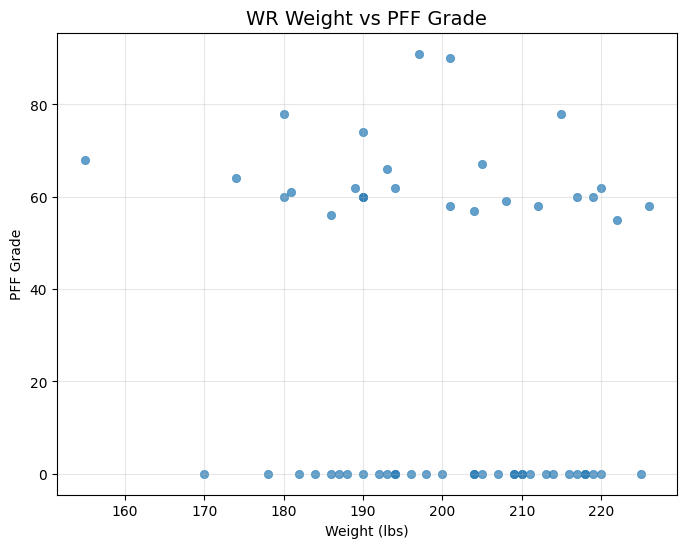

In [82]:
WR_df = WR_df.dropna(subset=["Weight", "PFF"])
WR_df = WR_df[(WR_df["Weight"] > 140) & (WR_df["Weight"] < 280)]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=WR_df,
    x="Weight",
    y="PFF",
    alpha=0.7,
    edgecolor=None
)

plt.title("WR Weight vs PFF Grade", fontsize=14)
plt.xlabel("Weight (lbs)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)

plt.show()

In [84]:
good_WR_df = WR_df[WR_df["PFF"] > 40]
good_WR_df

,Name,Pos,School,Height,Weight,40 Yd,Vertical,Broad,Bench,3-Cone,Shuttle,PFF,PFF_label,PFF_binary,FF_binary
2,Amari Rodgers,WR,Clemson,"5'9""",212.0,4.52,33.0,"10'1""",19.0,7.07,4.31,58.0,0,0,0
3,Amon-Ra St. Brown,WR,USC,"5'11""",197.0,4.51,38.5,"10'7""",20.0,6.88,4.17,91.0,3,1,1
4,Anthony Schwartz,WR,Auburn,"6'0""",186.0,4.27,32.0,"10'3""",0.0,7.13,4.25,56.0,0,0,0
10,Ben Skowronek,WR,Notre Dame,"6'2""",220.0,0.00,0.0,0,13.0,0.00,0.00,62.0,1,1,1
29,Cornell Powell,WR,Clemson,"6'0""",204.0,4.53,36.5,"10'8""",16.0,7.03,4.21,57.0,0,0,0
30,D'Wayne Eskridge,WR,West. Michigan,"5'8""",190.0,4.38,35.0,"10'4""",0.0,6.93,4.22,60.0,1,1,1
37,Dazz Newsome,WR,North Carolina,"5'10""",190.0,4.59,34.0,"10'1""",12.0,7.38,4.38,60.0,1,1,1
42,Dez Fitzpatrick,WR,Louisville,"6'1""",208.0,4.43,35.0,0,0.0,7.09,4.26,59.0,0,0,0
44,Dyami Brown,WR,North Carolina,"6'0""",189.0,4.46,35.0,"10'8""",18.0,6.87,4.35,62.0,1,1,1
49,Frank Darby,WR,Arizona St.,"6'0""",201.0,4.56,34.5,"9'9""",19.0,7.05,4.25,58.0,0,0,0


In [85]:
PFF_labels_good = good_WR_df["PFF"]

features_good = good_WR_df.drop(['Name', 'Pos', 'School', 'Height','PFF', 'PFF_binary', 'Broad'], axis=1)

train_vectors_good, test_vectors_good, train_labels_good, test_labels_good = train_test_split(features_good, PFF_labels_good, test_size=0.25, random_state=42)

model = LinearRegression()
model.fit(train_vectors_good, train_labels_good)

preds = model.predict(test_vectors_good)

X = sm.add_constant(train_vectors_good)
model = sm.OLS(train_labels_good, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PFF   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     34.37
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           7.42e-06
Time:                        02:01:17   Log-Likelihood:                -34.647
No. Observations:                  18   AIC:                             87.29
Df Residuals:                       9   BIC:                             95.31
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.1659     13.192      4.636      0.0

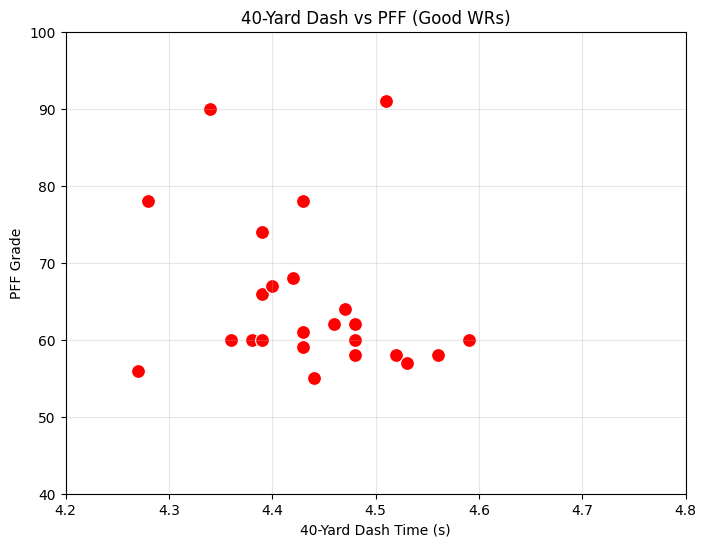

In [93]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=good_WR_df,
    x="40 Yd",
    y="PFF",
    s = 100,
    color = 'red'
)
plt.xlim(4.2, 4.8)
plt.ylim(40, 100)
plt.title("40-Yard Dash vs PFF (Good WRs)")
plt.xlabel("40-Yard Dash Time (s)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)
plt.show()

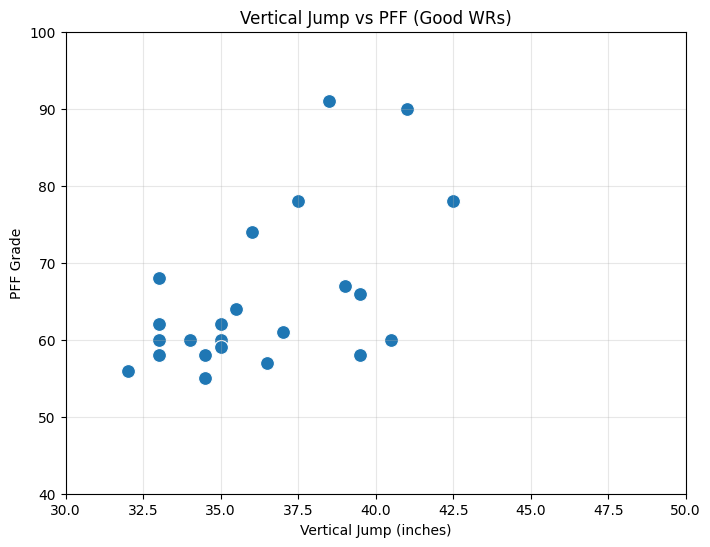

In [96]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=good_WR_df,
    x="Vertical",
    y="PFF",
    s = 100
)

plt.xlim(30, 50)
plt.ylim(40, 100)
plt.title("Vertical Jump vs PFF (Good WRs)")
plt.xlabel("Vertical Jump (inches)")
plt.ylabel("PFF Grade")

plt.grid(True, alpha=0.3)
plt.show()